In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('olist_cleaned.csv')
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

In [4]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,TotalPrice
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,29.99
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,118.70
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,159.90
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,45.00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,19.90


In [5]:
top_products = df.groupby('product_id')['TotalPrice'].sum().sort_values(ascending=False).head(10)

In [6]:
top_products.head(10)

,TotalPrice
product_id,
bb50f2e236e5eea0100680137654686c,63560.00
6cdd53843498f92890544667809f1595,53652.30
d6160fb7873f184099d9bc95e30376af,45949.35
d1c427060a0f73f6b889a5c7c61f2ac4,45620.56
99a4788cb24856965c36a24e339b6058,42049.66
3dd2a17168ec895c781a9191c1e95ad7,40782.80
25c38557cf793876c5abdd5931f922db,38907.32
5f504b3a1c75b73d6151be81eb05bdc9,37733.90
53b36df67ebb7c41585e8d54d6772e08,37454.63


In [7]:
top_customers = df.groupby('customer_unique_id')['TotalPrice'].sum().sort_values(ascending=False).head(10)
top_customers.head(10)

,TotalPrice
customer_unique_id,
0a0a92112bd4c708ca5fde585afaa872,13440.0
da122df9eeddfedc1dc1f5349a1a690c,7388.0
763c8b1c9c68a0229c42c9fc6f662b93,7160.0
dc4802a71eae9be1dd28f5d788ceb526,6735.0
459bef486812aa25204be022145caa62,6729.0
ff4159b92c40ebe40454e3e6a7c35ed6,6499.0
4007669dec559734d6f53e029e360987,5934.6
eebb5dda148d3893cdaf5b5ca3040ccb,4690.0
48e1ac109decbb87765a3eade6854098,4590.0


In [10]:
df['YearMonth'] = df['order_purchase_timestamp'].dt.to_period('M')
monthly_sales = df.groupby('YearMonth')['TotalPrice'].sum()

In [13]:
monthly_sales.head()

,TotalPrice
YearMonth,
2016-09,134.97
2016-10,40325.11
2016-12,10.90
2017-01,111798.36
2017-02,234223.40


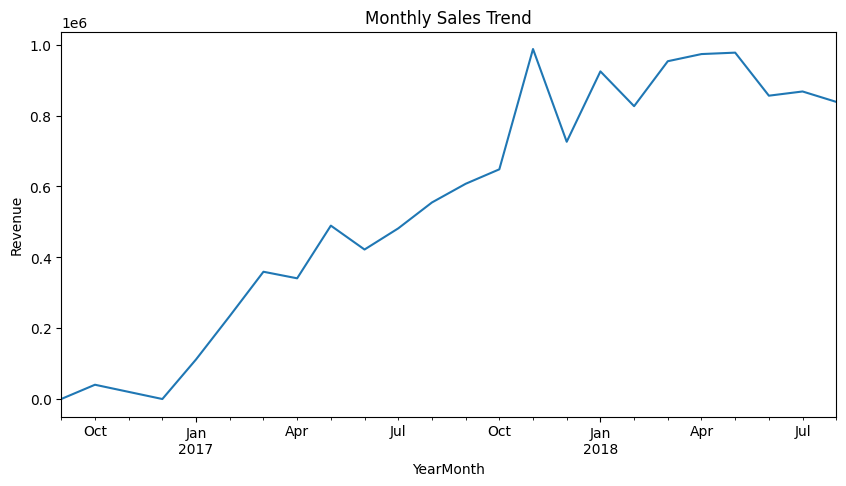

In [12]:
monthly_sales.plot(kind='line', figsize=(10,5), title='Monthly Sales Trend')
plt.ylabel('Revenue')
plt.show()

In [16]:
state_sales = df.groupby('customer_state')['TotalPrice'].sum().sort_values(ascending=False).head(10)

In [17]:
state_sales.head()

,TotalPrice
customer_state,
SP,5067633.16
RJ,1759651.13
MG,1552481.83
RS,728897.47
PR,666063.51


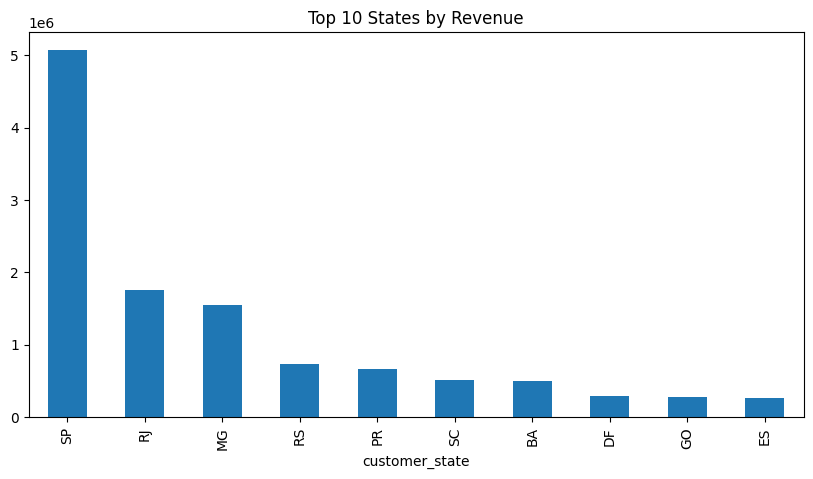

In [18]:
state_sales.plot(kind='bar', figsize=(10,5), title='Top 10 States by Revenue')
plt.show()

In [19]:
orders_per_customer = df.groupby('customer_unique_id')['order_id'].nunique()

In [20]:
orders_per_customer.head()

,order_id
customer_unique_id,
0000366f3b9a7992bf8c76cfdf3221e2,1
0000b849f77a49e4a4ce2b2a4ca5be3f,1
0000f46a3911fa3c0805444483337064,1
0000f6ccb0745a6a4b88665a16c9f078,1
0004aac84e0df4da2b147fca70cf8255,1


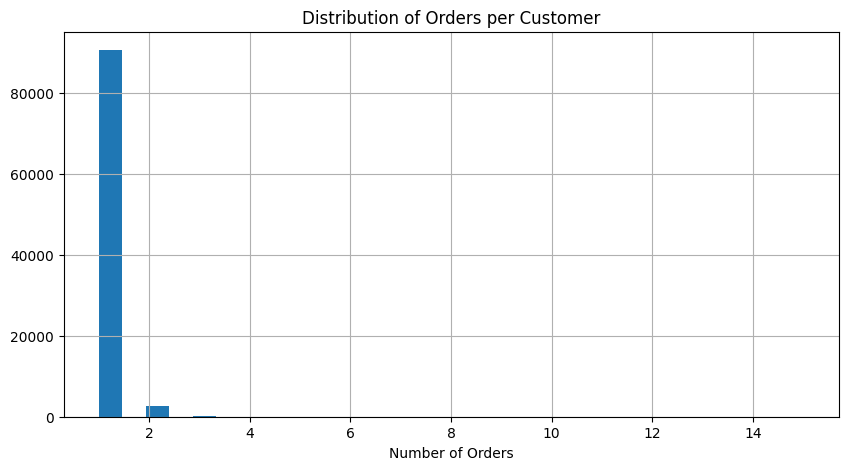

In [21]:
orders_per_customer.hist(bins=30, figsize=(10,5))
plt.title('Distribution of Orders per Customer')
plt.xlabel('Number of Orders')
plt.show()